# PW02 - KNN for Supervised Classification and Regression

**Team:** Noé Berdoz, Michael Strefeler

## Preamble: our starting level

- **Noé Berdoz**: Bachelor in Business Information Technology (Informatique de gestion) at HE-Arc, completed in 2026. Background in software development, with little prior experience in machine learning before this course.
- **Michael Strefeler**: Bachelor in Computer and Communication Systems (ISC) at HEIG-VD, completed in 2025, with a specialisation in data science, so he had already seen some machine learning before this course.

We worked hard on this PW, sometimes until late in the evening. It taught us a lot, especially Noé, for whom most of these notions were new, and it refreshed several notions for Michael. We hope it can earn us a bonus point.

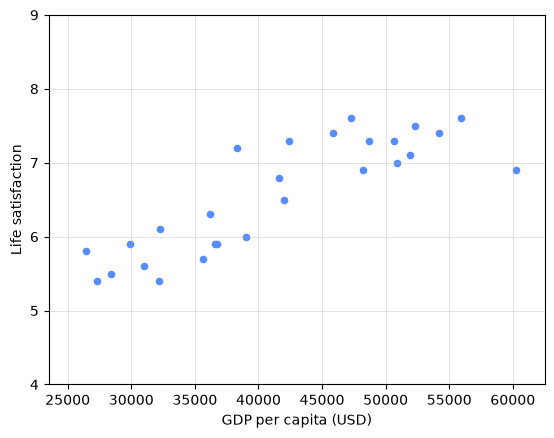

[[6.30165767]]


In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# Download and prepare the data
lifesat = pd.read_csv("lifesat.csv")
X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values

# Visualize the data
lifesat.plot(kind='scatter', grid=True,
             x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.show()

# Select a linear model
model = LinearRegression()

# Train the model
model.fit(X, y)

# Make a prediction for Cyprus
X_new = [[37_655.2]]  # Cyprus' GDP per capita in 2020
print(model.predict(X_new)) # outputs [[6.30165767]]


In [37]:
X_test = np.linspace(25000, 60000, 200)
X_test = [[value] for value in X_test]
y_test = model.predict(X_test)

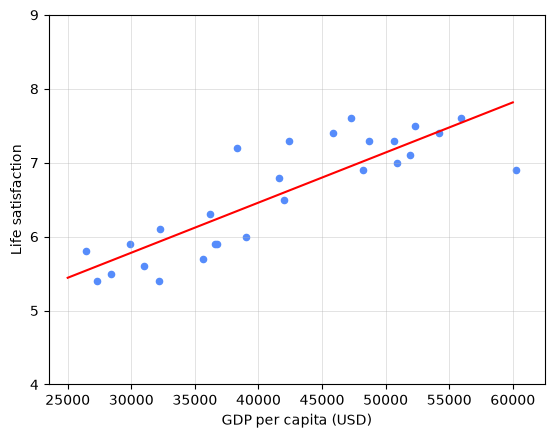

In [38]:
# Visualize the data
lifesat.plot(kind='scatter', grid=True,
             x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.plot(X_test, y_test, color='red')
plt.show()

In [39]:
class KNearestNeighborRegressor(object):
  """ a kNN regressor with L2 distance """

  def __init__(self):
    pass

  def train(self, X, y):
    """
    Train the classifier. For k-nearest neighbors this is just 
    memorizing the training data.

    Inputs:
    - X: A numpy array of shape (num_train, D) containing the training data
      consisting of num_train samples each of dimension D.
    - y: A numpy array of shape (N,) containing the training labels, where
         y[i] is the label for X[i].
    """
    self.X_train = X
    self.y_train = y
    
  def predict(self, X, k=1):
    """
    Predict labels for test data using this classifier.

    Inputs:
    - X: A numpy array of shape (num_test, D) containing test data consisting
         of num_test samples each of dimension D.
    - k: The number of nearest neighbors that vote for the predicted labels.
    - num_loops: Determines which implementation to use to compute distances
      between training points and testing points.

    Returns:
    - y: A numpy array of shape (num_test,) containing predicted labels for the
      test data, where y[i] is the predicted label for the test point X[i].  
    """
    dists = self.compute_distances(X)
    
    return self.predict_values(dists, k=k)


  def compute_distances(self, X):
    """
    Compute the distance between each test point in X and each training point
    in self.X_train using a single loop over the test data.

    Inputs:
    - X: A numpy array of shape (num_test, D) containing test data.

    Returns:
    - dists: A numpy array of shape (num_test, num_train) where dists[i, j]
      is the Euclidean distance between the ith test point and the jth training
      point.
    """
    num_test = X.shape[0]
    num_train = self.X_train.shape[0]
    dists = np.zeros((num_test, num_train))
    for i in range(num_test):
        #######################################################################
        # TODO:                                                               #
        # Compute the l2 distance between the ith test point and all training #
        # points, and store the result in dists[i, :].                        #
        #######################################################################
        
        # X[i] has shape (D,), self.X_train has shape (num_train, D):
        # broadcasting subtracts X[i] from every training row at once
        dists[i, :] = np.sqrt(np.sum((self.X_train - X[i]) ** 2, axis=1))
    
        #######################################################################
        #                         END OF YOUR CODE                            #
        #######################################################################
    return dists



  def predict_values(self, dists, k=1):
    """
    Given a matrix of distances between test points and training points,
    predict a value for each test point.

    Inputs:
    - dists: A numpy array of shape (num_test, num_train) where dists[i, j]
      gives the distance betwen the ith test point and the jth training point.

    Returns:
    - y: A numpy array of shape (num_test,) containing predicted values for the
      test data, where y[i] is the predicted value for the test point X[i].  
    """
    num_test = dists.shape[0]
    y_pred = np.zeros(num_test)
    for i in range(num_test):
        # A list of length k storing the labels of the k nearest neighbors to
        # the ith test point.
        closest_y = []
        
        #########################################################################
        # TODO:                                                                 #
        # Use the distance matrix to find the k nearest neighbors of the ith    #
        # testing point, and use self.y_train to find the labels of these       #
        # neighbors. Store these labels in closest_y.                           #
        # Hint: Look up the function numpy.argsort.                             #
        #########################################################################
        
        # Sort distance indices ascendingly and slice the k nearest
        closest_indices = np.argsort(dists[i])[:k]

        # Slicing directly with NumPy is faster than appending to
        # a Python list, we therefore did not append the values in
        # closest_y with a for loop as the scaffold code expected us to.
        closest_y = self.y_train[closest_indices]
    
        #########################################################################
        # TODO:                                                                 #
        # Now that you have found the labels of the k nearest neighbors, you    #
        # need to compute the average of the target values corresponding to the #
        # nearest neighbors.                                                    #
        #########################################################################
        
        y_pred[i] = np.mean(closest_y)
        
        #########################################################################
        #                           END OF YOUR CODE                            # 
        #########################################################################

    return y_pred

In [40]:
knn_reg = KNearestNeighborRegressor()
knn_reg.train(np.array(X), y)

In [41]:
y_hat_1 = knn_reg.predict(np.array(X_test), k=1)
y_hat_3 = knn_reg.predict(np.array(X_test), k=3)
y_hat_5 = knn_reg.predict(np.array(X_test), k=5)
y_hat_7 = knn_reg.predict(np.array(X_test), k=7)
y_hat_20 = knn_reg.predict(np.array(X_test), k=20)
y_hat_27 = knn_reg.predict(np.array(X_test), k=27)

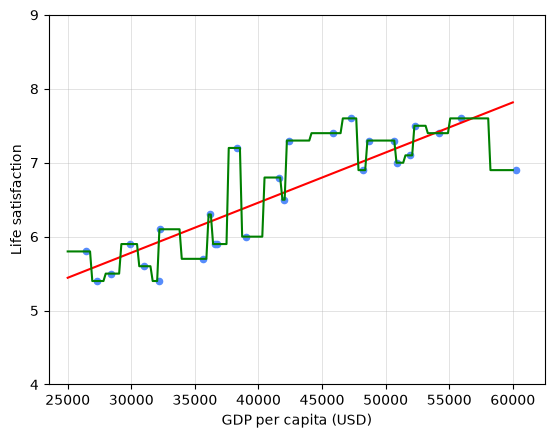

In [42]:
# Visualize the data
lifesat.plot(kind='scatter', grid=True,
             x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.plot(X_test, y_test, color='red')
plt.plot(X_test, y_hat_1, color='green')
# plt.plot(X_test, y_hat_3, color='blue')
# plt.plot(X_test, y_hat_5, color='magenta')
# plt.plot(X_test, y_hat_7, color='orange')
# plt.plot(X_test, y_hat_20, color='black')
# plt.plot(X_test, y_hat_27, color='grey')
plt.show()

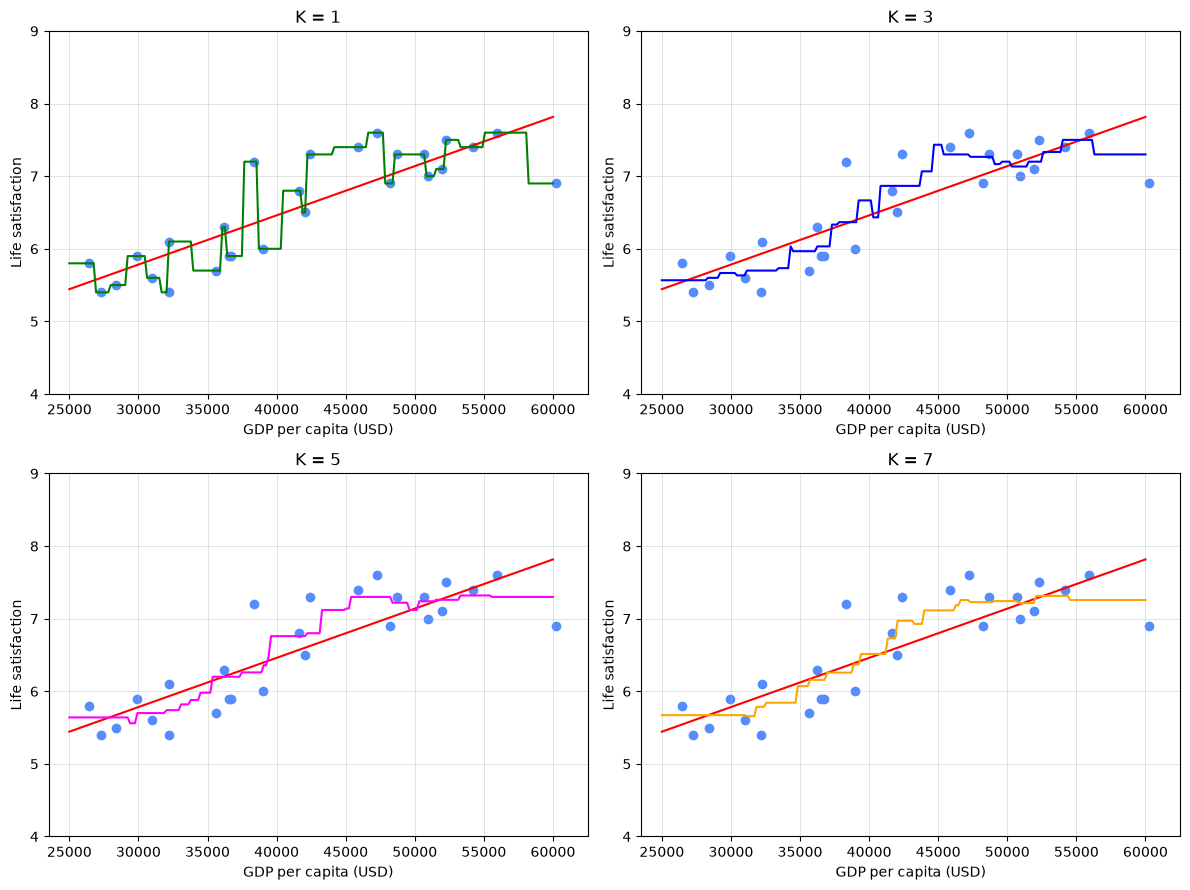

In [43]:
k_values = [1, 3, 5, 7]
predictions = [y_hat_1, y_hat_3, y_hat_5, y_hat_7]
colors = ['green', 'blue', 'magenta', 'orange']

plt.figure(figsize=(12, 9))
for i in range(4):
    plt.subplot(2, 2, i + 1)  # 2 rows, 2 columns, box number i + 1
    plt.scatter(X, y)
    plt.plot(X_test, y_test, color='red')
    plt.plot(X_test, predictions[i], color=colors[i])
    plt.axis([23_500, 62_500, 4, 9])
    plt.grid(True)
    plt.xlabel("GDP per capita (USD)")
    plt.ylabel("Life satisfaction")
    plt.title("K = " + str(k_values[i]))
plt.tight_layout()
plt.show()

Our curves for K = 1, 3, 5 and 7 match the figures of slide 42 ("Increasing k") of the course support.

# Questions to address in the report

## What is the predicted life satisfaction for Cyprus assuming that the GDP per capita is 38,341 USD?

In [44]:
X_cyprus = np.array([[38_341]])

for k in [1, 3, 5, 7]:
    y_pred = knn_reg.predict(X_cyprus, k=k)
    print("K =", k, "->", round(y_pred[0], 3))
print("Linear regression ->", round(model.predict(X_cyprus)[0][0], 3))

# The 7 countries closest to 38,341 USD, nearest first
dists = knn_reg.compute_distances(X_cyprus)
nearest = np.argsort(dists[0])[:7]
lifesat.iloc[nearest]

K = 1 -> 7.2
K = 3 -> 6.367
K = 5 -> 6.26
K = 7 -> 6.257
Linear regression -> 6.348


,Country,GDP per capita (USD),Life satisfaction
11,Israel,38341.307570,7.2
12,Italy,38992.148381,6.0
10,Lithuania,36732.034744,5.9
9,Slovenia,36547.738956,5.9
8,Spain,36215.447591,6.3
7,Estonia,35638.421351,5.7
13,United Kingdom,41627.129269,6.8


For Cyprus, KNN with K=1 predicts 7.2 (Israel alone). With K=3, it averages Israel, Italy, and Lithuania to predict ~6.37, which closely matches the linear model (6.35).

## What is the predicted life satisfaction for Switzerland assuming that the GDP per capita is 69,669 USD?

In [45]:
X_switzerland = np.array([[69_669]])  # GDP per capita given in the handout

for k in [1, 3, 5, 7]:
    y_pred = knn_reg.predict(X_switzerland, k=k)
    print("K =", k, "->", round(y_pred[0], 3))
print("Linear regression ->", round(model.predict(X_switzerland)[0][0], 3))

# The 7 countries closest to 69,669 USD, nearest first
dists = knn_reg.compute_distances(X_switzerland)
nearest = np.argsort(dists[0])[:7]
lifesat.iloc[nearest]

K = 1 -> 6.9
K = 3 -> 7.3
K = 5 -> 7.3
K = 7 -> 7.257
Linear regression -> 8.472


,Country,GDP per capita (USD),Life satisfaction
26,United States,60235.728492,6.9
25,Denmark,55938.212809,7.6
24,Netherlands,54209.563836,7.4
23,Iceland,52279.728851,7.5
22,Austria,51935.603862,7.1
21,Germany,50922.358023,7.0
20,Sweden,50683.323510,7.3


For Switzerland, kNN predicts 7.30 for both K=3 (US, Denmark, Netherlands) and K=5, the prediction stays identical because the two added neighbors average the same ((Iceland (7.5) + Austria (7.1)) / 2 = 7.30).

As Switzerland's GDP is higher than every country in the dataset, kNN cannot extrapolate, it pools the richest neighbors, so any higher GDP will flatline at 7.30. In contrast, linear regression extends its trend line and predicts 8.47, which is higher than every actual score in the data (max 7.6).

## What becomes the prediction when K is approaching N (the number of points in the training set). Do the experiment with K = 20 and K = 27, report your observation.

K = 20: from 6.325 to 6.88
K = 27: from 6.567 to 6.567
mean of all y: 6.567
K = 27 equals the mean everywhere: True


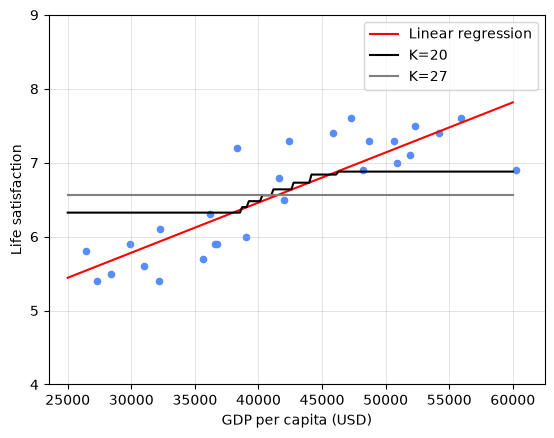

In [46]:
print("K = 20: from", round(y_hat_20.min(), 3), "to", round(y_hat_20.max(), 3))
print("K = 27: from", round(y_hat_27.min(), 3), "to", round(y_hat_27.max(), 3))
print("mean of all y:", round(y.mean(), 3))
print("K = 27 equals the mean everywhere:", np.allclose(y_hat_27, y.mean()))

lifesat.plot(kind="scatter", grid=True, x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.plot(X_test, y_test, color="red", label="Linear regression")
plt.plot(X_test, y_hat_20, color="black", label="K=20")
plt.plot(X_test, y_hat_27, color="grey", label="K=27")
plt.legend()
plt.show()

As K increases toward N = 27, the curve flattens because each prediction averages more countries. At K = 20, the output barely changes (6.325 to 6.88). At K = 27 (K = N) it's underfit, every prediction simply equals the overall dataset mean (6.567), ignoring GDP completely. This is the opposite extreme of K = 1, which overfits by chasing every single data point.